## 시각화의 중요성 :  앤스컴(Anscombe)의 예


### Anscombe's quartet
- 평균, 표본분산, 상관, 선형회귀선, 결정계수 등의 기술통계량이 동일하지만 분포나 그래프를 이용하여 시각화하면 전혀 다른 4개의 데이터 세트

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(f'numpy : {np.__version__}, pandas : {pd.__version__}')

numpy : 2.5.2, pandas : 3.0.5


In [3]:
data = np.load('data/anscombe.npy')
data.shape

(4, 11, 2)

In [4]:
data

array([[[10.  ,  8.04],
        [ 8.  ,  6.95],
        [13.  ,  7.58],
        [ 9.  ,  8.81],
        [11.  ,  8.33],
        [14.  ,  9.96],
        [ 6.  ,  7.24],
        [ 4.  ,  4.26],
        [12.  , 10.84],
        [ 7.  ,  4.82],
        [ 5.  ,  5.68]],

       [[10.  ,  9.14],
        [ 8.  ,  8.14],
        [13.  ,  8.74],
        [ 9.  ,  8.77],
        [11.  ,  9.26],
        [14.  ,  8.1 ],
        [ 6.  ,  6.13],
        [ 4.  ,  3.1 ],
        [12.  ,  9.13],
        [ 7.  ,  7.26],
        [ 5.  ,  4.74]],

       [[10.  ,  7.46],
        [ 8.  ,  6.77],
        [13.  , 12.74],
        [ 9.  ,  7.11],
        [11.  ,  7.81],
        [14.  ,  8.84],
        [ 6.  ,  6.08],
        [ 4.  ,  5.39],
        [12.  ,  8.15],
        [ 7.  ,  6.42],
        [ 5.  ,  5.73]],

       [[ 8.  ,  6.58],
        [ 8.  ,  5.76],
        [ 8.  ,  7.71],
        [ 8.  ,  8.84],
        [ 8.  ,  8.47],
        [ 8.  ,  7.04],
        [ 8.  ,  5.25],
        [19.  , 12.5 ],
        [ 

#### np.polyfit(x, y, deg, rcond=None, full=False, w=None, cov=False)

Least squares polynomial fit.

- np.mean(x)
- np.var(x)
- np.mean(y)
- np.var(y)
- np.corrcoef(x,y)[0,1]
- np.polyfit(x,y,1)  # y=ax^+b를 위한 [a, b]

In [5]:
for i, d in enumerate(data):
    print(f'data{i+1}:\n{d}')

data1:
[[10.    8.04]
 [ 8.    6.95]
 [13.    7.58]
 [ 9.    8.81]
 [11.    8.33]
 [14.    9.96]
 [ 6.    7.24]
 [ 4.    4.26]
 [12.   10.84]
 [ 7.    4.82]
 [ 5.    5.68]]
data2:
[[10.    9.14]
 [ 8.    8.14]
 [13.    8.74]
 [ 9.    8.77]
 [11.    9.26]
 [14.    8.1 ]
 [ 6.    6.13]
 [ 4.    3.1 ]
 [12.    9.13]
 [ 7.    7.26]
 [ 5.    4.74]]
data3:
[[10.    7.46]
 [ 8.    6.77]
 [13.   12.74]
 [ 9.    7.11]
 [11.    7.81]
 [14.    8.84]
 [ 6.    6.08]
 [ 4.    5.39]
 [12.    8.15]
 [ 7.    6.42]
 [ 5.    5.73]]
data4:
[[ 8.    6.58]
 [ 8.    5.76]
 [ 8.    7.71]
 [ 8.    8.84]
 [ 8.    8.47]
 [ 8.    7.04]
 [ 8.    5.25]
 [19.   12.5 ]
 [ 8.    5.56]
 [ 8.    7.91]
 [ 8.    6.89]]


In [10]:
stat_df = pd.DataFrame()

In [11]:
for i, d in enumerate(data):
    x = d[:,0]
    y = d[:,1]
    poly_fit = np.polyfit(x,y,1)
    a = poly_fit[0]
    b = poly_fit[1]
    poly = f'{a:.2f}x+{b:.2f}'
    mean_X, mean_Y = np.mean(x), np.mean(y)
    var_X, var_Y = np.var(x), np.var(y)
    corr = np.corrcoef(x,y)[0,1]
    # print('poly',poly)
    # print(f'meanX:{mean_X}, meanY:{mean_Y}, varX:{var_X}, varY:{var_Y}')
    stat_df[f'data{i+1}'] = [np.round(mean_X,2), np.round(var_X,2),
                             np.round(mean_Y,2), np.round(var_Y,2),
                             np.round(corr,2), poly]
stat_df

,data1,data2,data3,data4
0,9.0,9.0,9.0,9.0
1,10.0,10.0,10.0,10.0
2,7.5,7.5,7.5,7.5
3,3.75,3.75,3.75,3.75
4,0.82,0.82,0.82,0.82
5,0.50x+3.00,0.50x+3.00,0.50x+3.00,0.50x+3.00


### 시각화

- 네 가지 데이터에 대한 산점도와 회귀직선

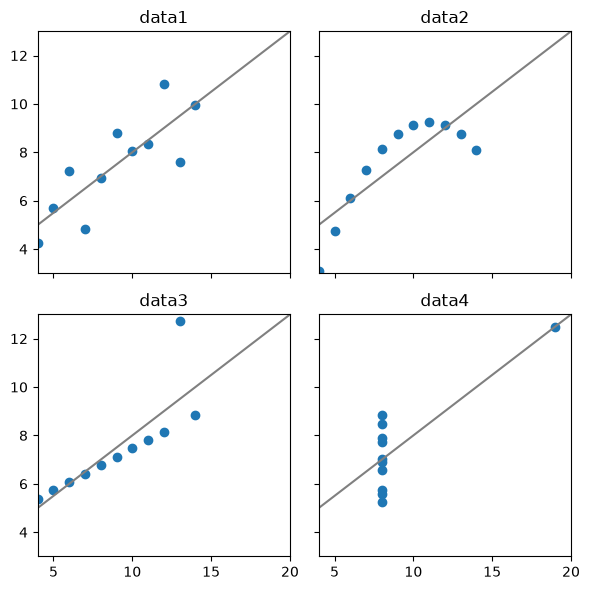

In [12]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(6,6),
                        sharex=True, sharey = True)
x = np.linspace(0,30,100)
for i, d in enumerate(data):
    poly_fit = np.polyfit(d[:,0], d[:,1], 1)
    poly_1d = np.poly1d(poly_fit)
    y = poly_1d(x)
    ax = axs[i//2, i%2]
    ax.scatter(d[:,0], d[:,1])   # 데이터
    ax.plot(x, y, color='gray')  # 회귀직선
    ax.set_xlim([4,20])
    ax.set_ylim([3,13])
    ax.set_title(f'data{i+1}')
plt.tight_layout()
plt.show()

=> 기술통계와 분석 결과가 모두 동일한 4개의 데이터에 대하여 시각화를 한 결과, 데이터 분포 모양이 다름을 확인

-------